# xLSTM Embedding PCA + K-means Analysis
This notebook extracts xLSTM model embeddings, applies PCA for dimensionality reduction, and uses K-means clustering to explain the embedding structure.


In [2]:
import os
import json
import sys
from typing import Dict

import torch
import numpy as np
import obspy
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

with open("../config/paths.json", "r") as file:
    paths = json.load(file)
with open("../config/data_parameters.json", "r") as file:
    data_params = json.load(file)

sys.path.append(paths["LOCAL_BASE_DIR"])
from models.xLSTM_model import xLSTMRegressor_v2
from functions.data_processing.read_data import load_data_test, load_seismic_data_test
from functions.data_processing.dataloader import SequenceDatasetTest, DataLoader

plt.rcParams.update({
    "font.size": 8,
    "font.family": "Arial",
    "legend.fontsize": 7,
    "figure.figsize": (6.0, 4.0),
    "axes.formatter.limits": (-3, 6),
    "axes.formatter.use_mathtext": True,
})


In [262]:
from matplotlib.patches import Ellipse

def load_model(sub_interval: int, model_index: int = 1) -> xLSTMRegressor_v2:
    config_path = os.path.join(paths["LOCAL_BASE_DIR"], "config", "comparison_baseline_cv",
                               f"xlstm_v4_{sub_interval}sec_config.json")
    with open(config_path, "r") as file:
        config = json.load(file)

    model = xLSTMRegressor_v2(**config)
    model_path = os.path.join(paths["LOCAL_BASE_DIR"], paths["SAVED_MODEL_DIR"],
                              "v4", str(model_index), f"{sub_interval}_xLSTM.pt")
    state_dict = torch.load(model_path, map_location=torch.device("cpu"))
    model.load_state_dict(state_dict)
    model.eval()
    return model


def build_case(julday: int, station: str, year: int, component: str, network: str,
               interval_seconds: int, freq: int):
    st = load_seismic_data_test(julday=julday, station=station, year=year,
                                component=component, network=network, freq=freq)
    
    starttime = UTCDateTime("2019-06-21T19:30:00")
    endtime = UTCDateTime("2019-06-21T21:00:00")
    st.trim(starttime, endtime)
    # data, _ = load_data_test(julday_list=[julday], station=station, year=year, abs=True)
    total_timestamps = st[0].times('matplotlib')[1:]
    timestamps = np.array([t for t in st[0].times("timestamp")])[5*60*100::5*100]
    data_envelope = obspy.signal.filter.envelope(st[0].data)
    data = data_envelope
    data = data[1:]


    return st, data, timestamps


def build_dataloader(data: np.ndarray, timestamps: np.ndarray,
                     interval_count: int = 60, sequence_length: int = 5 * 100):
    dataset = SequenceDatasetTest(input_data=data, target_time=timestamps,
                                  interval_count=interval_count,
                                  sequence_length=sequence_length)
    dataloader = DataLoader(dataset=dataset, batch_size=len(timestamps), shuffle=False)
    return dataloader


def extract_xlstm_embeddings(model: xLSTMRegressor_v2, dataloader):
    outputs = []
    embeddings = []
    xlstm_embeddings = []
    with torch.no_grad():
        for input_sequences, _ in dataloader:
            output = model(input_sequences)
            outputs.append(output.squeeze().numpy())
            layer_embeddings = model.get_embeddings(input_sequences)
            if isinstance(layer_embeddings, torch.Tensor):
                arr = layer_embeddings.squeeze().cpu().numpy()
            else:
                arr = np.asarray(layer_embeddings).squeeze()
            embeddings.append(arr)

            model_embeddings = model.get_xlstm_embeddings(input_sequences)
            if isinstance(model_embeddings, torch.Tensor):
                arr = model_embeddings.squeeze().cpu().numpy()
            else:
                arr = np.asarray(model_embeddings).squeeze()

            xlstm_embeddings.append(arr)

    return np.array(outputs), np.array(embeddings), np.array(xlstm_embeddings)


def fit_pca(embeddings: np.ndarray, n_components: int = 2):
    pca = PCA(n_components=n_components, random_state=0)
    projection = pca.fit_transform(embeddings)
    return pca, projection


def run_kmeans(projection: np.ndarray, n_clusters: int = 3):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    labels = kmeans.fit_predict(projection)
    return kmeans, labels


def plot_embedding_projection(projection: np.ndarray, labels: np.ndarray,
                              title: str, save_path: str = None):

    fig, ax = plt.subplots(figsize=(6, 4))
    colors = np.array(["black", "blue", "green"])
    scatter = ax.scatter(projection[:, 0], projection[:, 1],
                         c=colors[labels], s=35, alpha=0.75)
    ax.set_xlabel("PCA component 1")
    ax.set_ylabel("PCA component 2")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.25)
    # legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=12)
    # plt.setp(legend1.get_title(),fontsize=12)
    # ax.add_artist(legend1)

    unique_labels = np.unique(labels)
    centers = {}
    for label in unique_labels:
        pts = projection[labels == label]
        if pts.shape[0] < 2:
            continue
        center = pts.mean(axis=0)
        centers[label] = center
        cov = np.cov(pts.T)
        eigenvals, eigenvecs = np.linalg.eigh(cov)
        order = eigenvals.argsort()[::-1]
        eigenvals = eigenvals[order]
        eigenvecs = eigenvecs[:, order]
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
        width, height = 2 * np.sqrt(eigenvals) * 2
        ellipse = Ellipse(xy=center, width=width, height=height, angle=angle,
                          edgecolor="black", fc="none", lw=1.5, ls="--")
        ax.add_patch(ellipse)

    if len(centers) == 2:
        center_items = [(label, np.linalg.norm(center)) for label, center in centers.items()]
        background_label = min(center_items, key=lambda x: x[1])[0]
        debris_label = max(center_items, key=lambda x: x[1])[0]

        for label, text in [(background_label, "background"), (debris_label, "debris flow")]:
            coord = centers[label]
            ax.annotate(text, xy=coord, xytext=(0, -15), textcoords="offset points",
                        va="top", ha="center", fontsize=10, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
                        arrowprops=dict(arrowstyle="-", lw=0.8))
    elif len(centers) == 3:
        sorted_labels = sorted(centers.keys(), key=lambda k: np.linalg.norm(centers[k]))
        background_label, transition_label, debris_label = 0, 1, 2

        for label, text in [(background_label, "background"),
                            (transition_label, "debris flow\ntail"),
                            (debris_label, "debris flow\nfront")]:
            coord = centers[label]
            ax.annotate(text, xy=coord, xytext=(0, -25), textcoords="offset points",
                        va="top", ha="center", fontsize=10, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
                        arrowprops=dict(arrowstyle="-", lw=0.8))
    elif len(centers) > 0:
        for label, center in centers.items():
            ax.annotate(f"cluster {label}", xy=center, xytext=(0, -15), textcoords="offset points",
                        va="top", ha="center", fontsize=9,
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    if save_path:
        fig.tight_layout()
        fig.savefig(save_path, dpi=300, transparent=False)
    return fig, ax


def print_cluster_summary(labels: np.ndarray):
    unique, counts = np.unique(labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        print(f"Cluster {cluster}: {count} samples")
    print(f"Total samples: {labels.shape[0]}")

import numpy as np
from datetime import datetime
from obspy import read, Trace, Stream, read_inventory, signal, UTCDateTime

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def convert_st2tr(st):

    if isinstance(st, Stream):
        st = st[0]
    elif isinstance(st, Trace):
        pass
    else:
        print(f"!!! Error\n"
              f"Make sure the input for <convert_st2tr> is Obspy 'Trace' or 'Stream'.")

    return st

def rewrite_x_ticks(ax, data_start, data_end, data_sps, x_interval=1):
    '''
    Re write the x/time ticks

    Args:
        ax:
        data_start:
        data_end:
        data_sps:
        x_interval: for PSD, levea it as 1, for waveform or other, set as SPS

    Returns:

    '''
    start = UTCDateTime(data_start).timestamp
    end = UTCDateTime(data_end).timestamp

    x_location = np.arange(start, end + 1, 3600 * x_interval)
    x_ticks = []
    for j, k in enumerate(x_location):
        if j == 0:
            fmt = "%Y-%m-%d\n%H:%M:%S"
        else:
            fmt = "%H:%M"
        x_ticks.append(datetime.utcfromtimestamp(int(k)).strftime(fmt))

    x_location = (x_location - start) * data_sps

    ax.set_xticks(x_location, x_ticks)

def psd_plot(fig, ax, cbar_ax, st, fix_colorbar=True, per_lap=0.5, wlen=60, x_interval=1):

    st = convert_st2tr(st)
    st.spectrogram(per_lap=per_lap, wlen=wlen, log=False, dbscale=True, mult=True, title="", axes=ax, cmap='inferno')
    data_sps = 1 / (per_lap * wlen)

    if fix_colorbar is True:
        ax.images[0].set_clim(-180, -100) # from experiences

    ax.set_ylim(1, 30)
    ax.set_yticks([1, 5, 10, 15, 20, 25, 30], [1, 5, 10, 15, 20, 25, 30])
    ax.set_ylabel('Frequency [Hz]', weight='bold', fontsize=12)

    if cbar_ax is not None:
        cbar = fig.colorbar(ax.images[0], cax=cbar_ax, orientation="vertical")
        cbar.set_label("Power Spectral Density (dB)")

    rewrite_x_ticks(ax,
                    data_start=st.stats.starttime,
                    data_end=st.stats.endtime,
                    data_sps=1, # fixed for psd
                    x_interval=x_interval)


    return ax, data_sps

def waveform_plot(ax, st, x_interval=1):

    st = convert_st2tr(st)
    data_source = f"{st.stats.network}-{st.stats.station}-{st.stats.channel}-SPS={int(st.stats.sampling_rate)}"

    ax.plot(st.data, color="black", label=data_source)
    ax.set_xlim(0, st.data.size)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(st.stats.sampling_rate * 3600 * x_interval))  # unit is saecond
    ax.legend(loc="upper left", fontsize=6)
    ax.set_ylabel('Ampitude\n[m/s]', weight='bold')

    rewrite_x_ticks(ax,
                    data_start=st.stats.starttime,
                    data_end=st.stats.endtime,
                    data_sps=st.stats.sampling_rate,
                    x_interval=x_interval)

    return ax


## Select case and load data
Choose a case, load the waveform data, and build the sequence dataloader.


In [228]:
case = {
    "julday": 172,
    "station": "ILL11",
    "year": 2019,
    "component": "EHZ",
    "network": "9S",
    "interval_seconds": 5,
    "freq": 30
}

st, data, timestamps = build_case(**case)
dataloader = build_dataloader(data=data, timestamps=timestamps,
                              interval_count=60, sequence_length=5 * 100)

print("Waveform sample count:", len(timestamps))
input_sequences, target_times = next(iter(dataloader))
print("Input sequences shape:", input_sequences.shape)


Waveform sample count: 1021
Input sequences shape: torch.Size([1021, 60, 500])


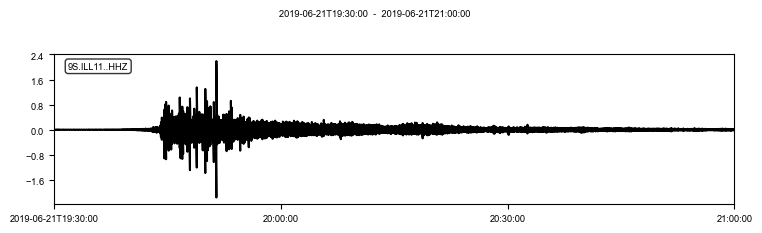

In [229]:
st.plot();

In [230]:
stt = st.copy()
stt[0].data = stt[0].data / 1e3

/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_57166/1039960208.py:201: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  x_ticks.append(datetime.utcfromtimestamp(int(k)).strftime(fmt))


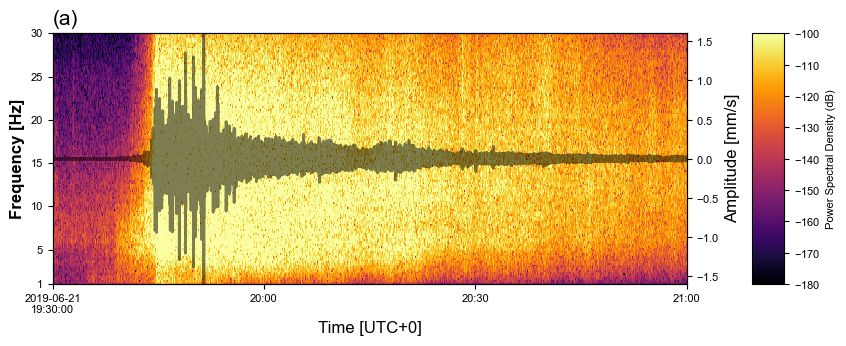

In [248]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.5), width_ratios=[1, 0.05])

psd_plot(fig, ax[0], ax[1], stt, True, per_lap=0.9, wlen=5, x_interval=0.5)
ax[0].set_xlabel("Time [UTC+0]", fontsize=12)

ax_t = ax[0].twinx()
ax_t.plot(np.arange(0, 5400, 0.01), st[0].data[1:], color="k", alpha=0.5, linewidth=2)
ax_t.set_ylim(-1.6, 1.6)
ax_t.set_ylabel("Amplitude [mm/s]", fontsize=12)
ax[0].set_title("(a)", loc="left", fontsize=15)
fig.tight_layout()
fig.savefig("./output_images13/waveform.png", dpi=600)

## Load xLSTM model and extract xLSTM embeddings
Use the model's `get_xlstm_embeddings` output as the feature representation for each sequence.


In [232]:
model = load_model(sub_interval=5, model_index=7)
print(model)
output, embeddings, xlstm_embeddings = extract_xlstm_embeddings(model, dataloader)

print("xlstm embeddings shape:", xlstm_embeddings.shape)


xLSTMRegressor_v2(
  (embedding): Linear(in_features=500, out_features=256, bias=True)
  (xlstm_layers): ModuleList(
    (0): xLSTMBlockStack(
      (blocks): ModuleList(
        (0): mLSTMBlock(
          (xlstm_norm): LayerNorm()
          (xlstm): mLSTMLayer(
            (proj_up): Linear(in_features=256, out_features=1024, bias=False)
            (q_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
            (k_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
            (v_proj): LinearHeadwiseExpand(in_features=512, num_heads=128, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
            (conv1d): CausalConv1d(
              (conv): Conv1d(512, 512, kernel_size=(4,), stride=(1,), padding=(3,), groups=512)
            )
            (conv_act_fn): SiLU()
            (mlstm_c

In [233]:
xlstm_embeddings.shape

(1, 1021, 60, 256)

## PCA dimensionality reduction
Project the aggregated xLSTM embeddings into 2 dimensions for visualization.


In [234]:
pca, embedding_2d = fit_pca(embeddings[0,:,-1,:], n_components=2)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("PCA projection shape:", embedding_2d.shape)

fig, ax = plot_embedding_projection(
    embedding_2d,
    labels=np.zeros(embedding_2d.shape[0], dtype=int),
    title="xLSTM embedding PCA projection",
    save_path="./output_images13/embedding_pca.png",
)



Explained variance ratio: [0.9771 0.0029]
PCA projection shape: (1021, 2)


## K-means clustering on PCA projection
Cluster the 2D PCA projection and summarize the resulting groups.


/opt/anaconda3/envs/xlstm_env/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster 0: 590 samples
Cluster 1: 310 samples
Cluster 2: 121 samples
Total samples: 1021


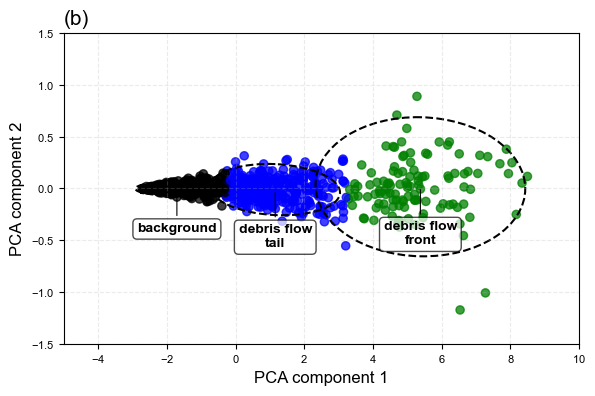

In [263]:
kmeans, labels = run_kmeans(embedding_2d, n_clusters=3)
print_cluster_summary(labels)

fig, ax = plot_embedding_projection(
    embedding_2d,
    labels=labels,
    title="",
    save_path="./output_images13/embedding_kmeans.png",
)
# K-means clusters on Embedding PCA projection
ax.set_title("(b)", loc="left", fontsize=15)
ax.set_ylabel("PCA component 2", fontsize=12)
ax.set_xlabel("PCA component 1", fontsize=12)
ax.set_ylim(-1.5, 1.5)
ax.set_xlim(-5, 10)

fig.tight_layout()
fig.savefig("./output_images13/embedding_kmeans.png", dpi=600)

## Cluster interpretation
Display cluster membership and sample indices so we can explain embedding structure.


In [251]:
indices_by_cluster = {cluster: np.where(labels == cluster)[0].tolist()
                      for cluster in np.unique(labels)}

for cluster, indices in indices_by_cluster.items():
    print(f"Cluster {cluster} sample indices: {indices[:10]}{'...' if len(indices) > 10 else ''}")


Cluster 0 sample indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Cluster 1 sample indices: [110, 111, 112, 113, 114, 226, 228, 230, 231, 232]...
Cluster 2 sample indices: [115, 116, 117, 118, 119, 120, 121, 122, 123, 124]...


In [252]:
input_sequences_np = input_sequences.cpu().numpy() if isinstance(input_sequences, torch.Tensor) else input_sequences
inp_seq = input_sequences_np[:, 30, :]
seq_len = inp_seq.shape[1]
n_sequences = inp_seq.shape[0]

total_timestamps = np.array(st[0].times("matplotlib")[1:])
sample_rate = st[0].stats.sampling_rate
sample_dt = 1.0 / sample_rate

if total_timestamps.size == n_sequences * seq_len:
    ts_matrix = total_timestamps.reshape(n_sequences, seq_len)
else:
    end_offset = (seq_len - 1) * sample_dt / 86400.0
    start_times = UTCDateTime(timestamps[0]).matplotlib_date - end_offset
    ts_matrix = np.tile(start_times + np.arange(seq_len) * sample_dt / 86400.0, (n_sequences, 1))

labels_pca = labels


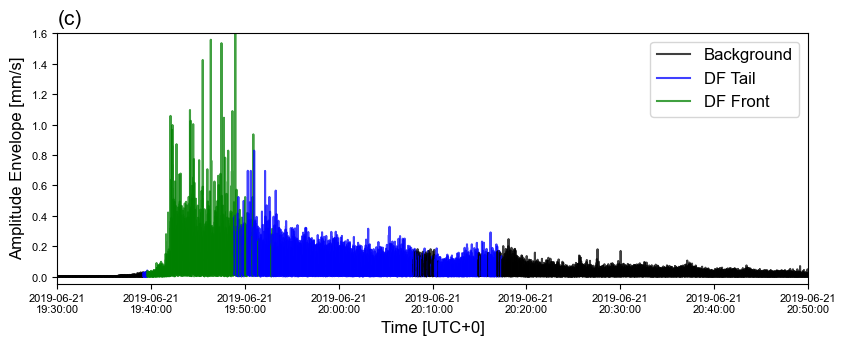

In [253]:
# Full sequence plot
fig, ax = plt.subplots(1, 1, figsize=(8.5, 3.5))
# cmap = plt.get_cmap("tab10")
label_seen = set()

for i in range(n_sequences):
    ts = total_timestamps[i * seq_len:(i + 1) * seq_len]
    cluster = int(labels_pca[i])
    color = ["black", "blue", "green"][cluster]
    label = ["Background", "DF Tail", "DF Front"][cluster] if cluster not in label_seen else None
    label_seen.add(cluster)
    ax.plot(ts, inp_seq[i, :], color=color, label=label, alpha=0.75)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
ax.set_xlim(UTCDateTime("2019-06-21T19:30:00").matplotlib_date, UTCDateTime("2019-06-21T20:50:00").matplotlib_date)
ax.set_ylim(-0.05, 1.6)
ax.set_ylabel("Amplitude Envelope [mm/s]", fontsize=12)
ax.set_xlabel("Time [UTC+0]", fontsize=12)
ax.legend(loc="best", fontsize=12)

ax.set_title("(c)", loc="left", fontsize=15)
fig.tight_layout()
fig.savefig("./output_images13/embedding_layers_full.png", dpi=300)
plt.show()


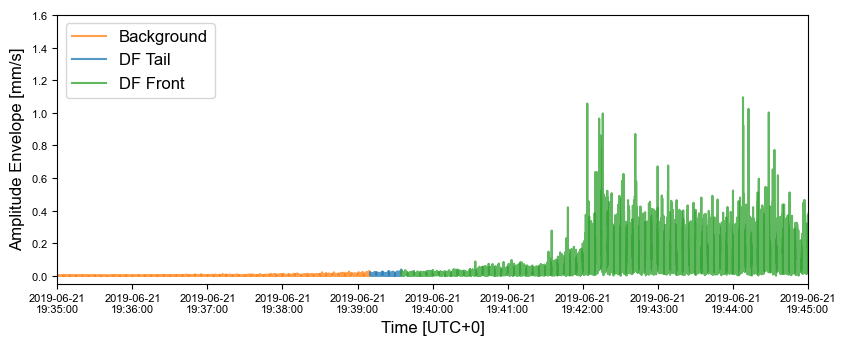

In [213]:
# Zoom view
fig, ax = plt.subplots(1, 1, figsize=(8.5, 3.5))
cmap = plt.get_cmap("tab10")
label_seen = set()

for i in range(n_sequences):
    ts = total_timestamps[i * seq_len:(i + 1) * seq_len]
    cluster = int(labels_pca[i])
    color = cmap(cluster)
    label = ["DF Tail", "Background", "DF Front"][cluster] if cluster not in label_seen else None
    label_seen.add(cluster)
    ax.plot(ts, inp_seq[i, :], color=color, label=label, alpha=0.75)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M:%S'))
ax.set_xlim(UTCDateTime("2019-06-21T19:35:00").matplotlib_date, UTCDateTime("2019-06-21T19:45:00").matplotlib_date)
ax.set_ylim(-0.05, 1.6)
ax.set_ylabel("Amplitude Envelope [mm/s]", fontsize=12)
ax.set_xlabel("Time [UTC+0]", fontsize=12)
ax.legend(loc="best", fontsize=12)

fig.tight_layout()
# fig.savefig("./output_images8/embedding_layers_full.png", dpi=300)
plt.show()


## Optional: compare multiple cases
Use the same functions to compare another event or time window.
